# Prediksi Student Dropout dengan Machine Learning

**Anggota:**
1. Raissa Christabel Sebayang (140810240008)
2. Jovianie Felisia Suryadi (140810240010)
3. Muhammad Fathin Raihan (140810240026)

**Tujuan:** Membangun dan membandingkan beberapa algoritma machine learning untuk memprediksi apakah seorang mahasiswa akan dropout atau tidak.

**Workflow:**
1. Import Library
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Modeling & Training
7. Evaluasi Model
8. Feature Importance
9. Cross Validation
10. Kesimpulan

Sumber Dataset:

[Student Dropout Prediction Dataset - Mehar Shan Ali](https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset)

## Import Library

In [1]:
import os
import warnings
import kagglehub
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

!pip install shap -q
import shap

import joblib
from sklearn.pipeline import Pipeline as SklearnPipeline

# Konfigurasi global
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
%%capture
!pip install imbalanced-learn

## Load Dataset

In [3]:
# Download dataset dari Kaggle
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
print("Path dataset:", path)

dataset_files = os.listdir(path)
print("File dalam direktori:", dataset_files)

csv_file_name = "student_dropout_dataset_v3.csv"
full_csv_path = os.path.join(path, csv_file_name)

if not os.path.exists(full_csv_path):
    raise FileNotFoundError(f"File '{csv_file_name}' tidak ditemukan di '{path}'.")

df = pd.read_csv(full_csv_path)
df.head()


100%|██████████| 255k/255k [00:00<00:00, 47.7MB/s]

Extracting files...
Path dataset: /root/.cache/kagglehub/datasets/meharshanali/student-dropout-prediction-dataset/versions/1
File dalam direktori: ['student_dropout_dataset_v3.csv']


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
# Info tipe data dan nilai non-null
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [5]:
# Statistik deskriptif
df.describe()


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


## Exploratory Data Analysis (EDA)


### Distribusi Target (Dropout)

                   Jumlah  Persentase (%)
Tidak Dropout (0)    7646           76.46
Dropout (1)          2354           23.54


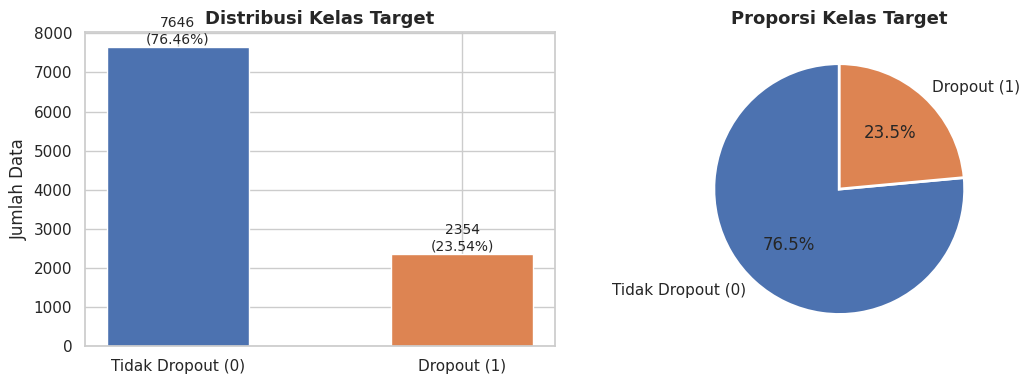

In [6]:
target_col = "Dropout"

target_count   = df[target_col].value_counts().sort_index()
target_percent = df[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Jumlah": target_count,
    "Persentase (%)": target_percent.round(2)
})
target_summary.index = ["Tidak Dropout (0)", "Dropout (1)"]
print(target_summary)

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ["#4C72B0", "#DD8452"]
axes[0].bar(target_summary.index, target_summary["Jumlah"], color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Distribusi Kelas Target", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Jumlah Data")
axes[0].set_xlabel("")
for i, (val, pct) in enumerate(zip(target_summary["Jumlah"], target_summary["Persentase (%)"])):
    axes[0].text(i, val + 20, f"{val}\n({pct}%)", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(
    target_summary["Jumlah"],
    labels=target_summary.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporsi Kelas Target", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


Dari grafik di atas, dapat diketahui bahwa terdapat imbalanced data pada target. Data lebih banyak pada mahasiswa yang tidak dropout sebanyak 76,46%, sementara yang tidak dropout sebanyak 23,5%. Hal ini dapat menjadi pertimbangan kedepannya untuk menangani data imbalanced ini.

### Cek Missing Value

Ditemukan 4 kolom dengan missing value:


,Missing,Persentase (%)
Parental_Education,511,5.11
Family_Income,500,5.00
Study_Hours_per_Day,500,5.00
Stress_Index,500,5.00


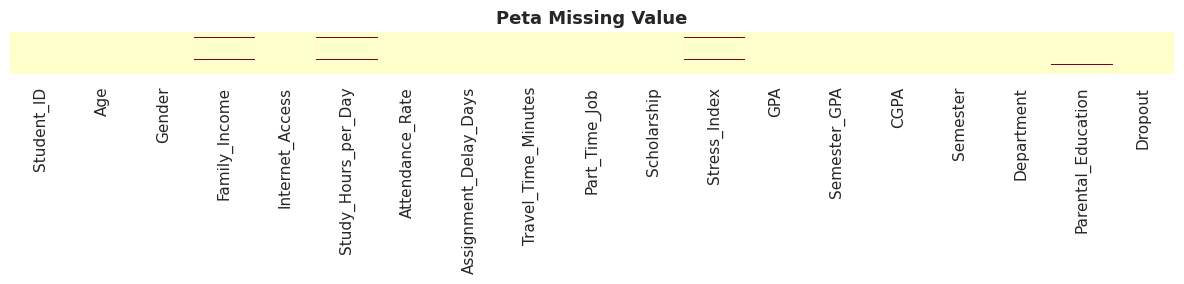

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Persentase (%)": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Missing", ascending=False)

if missing_df.empty:
    print("Tidak ada missing value dalam dataset.")
else:
    print(f"Ditemukan {len(missing_df)} kolom dengan missing value:")
    display(missing_df)

    # Heatmap missing value
    plt.figure(figsize=(12, 3))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="YlOrRd")
    plt.title("Peta Missing Value", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


### Deteksi Duplikat

In [8]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")

Jumlah baris duplikat: 0


### Distribusi Fitur Numerik

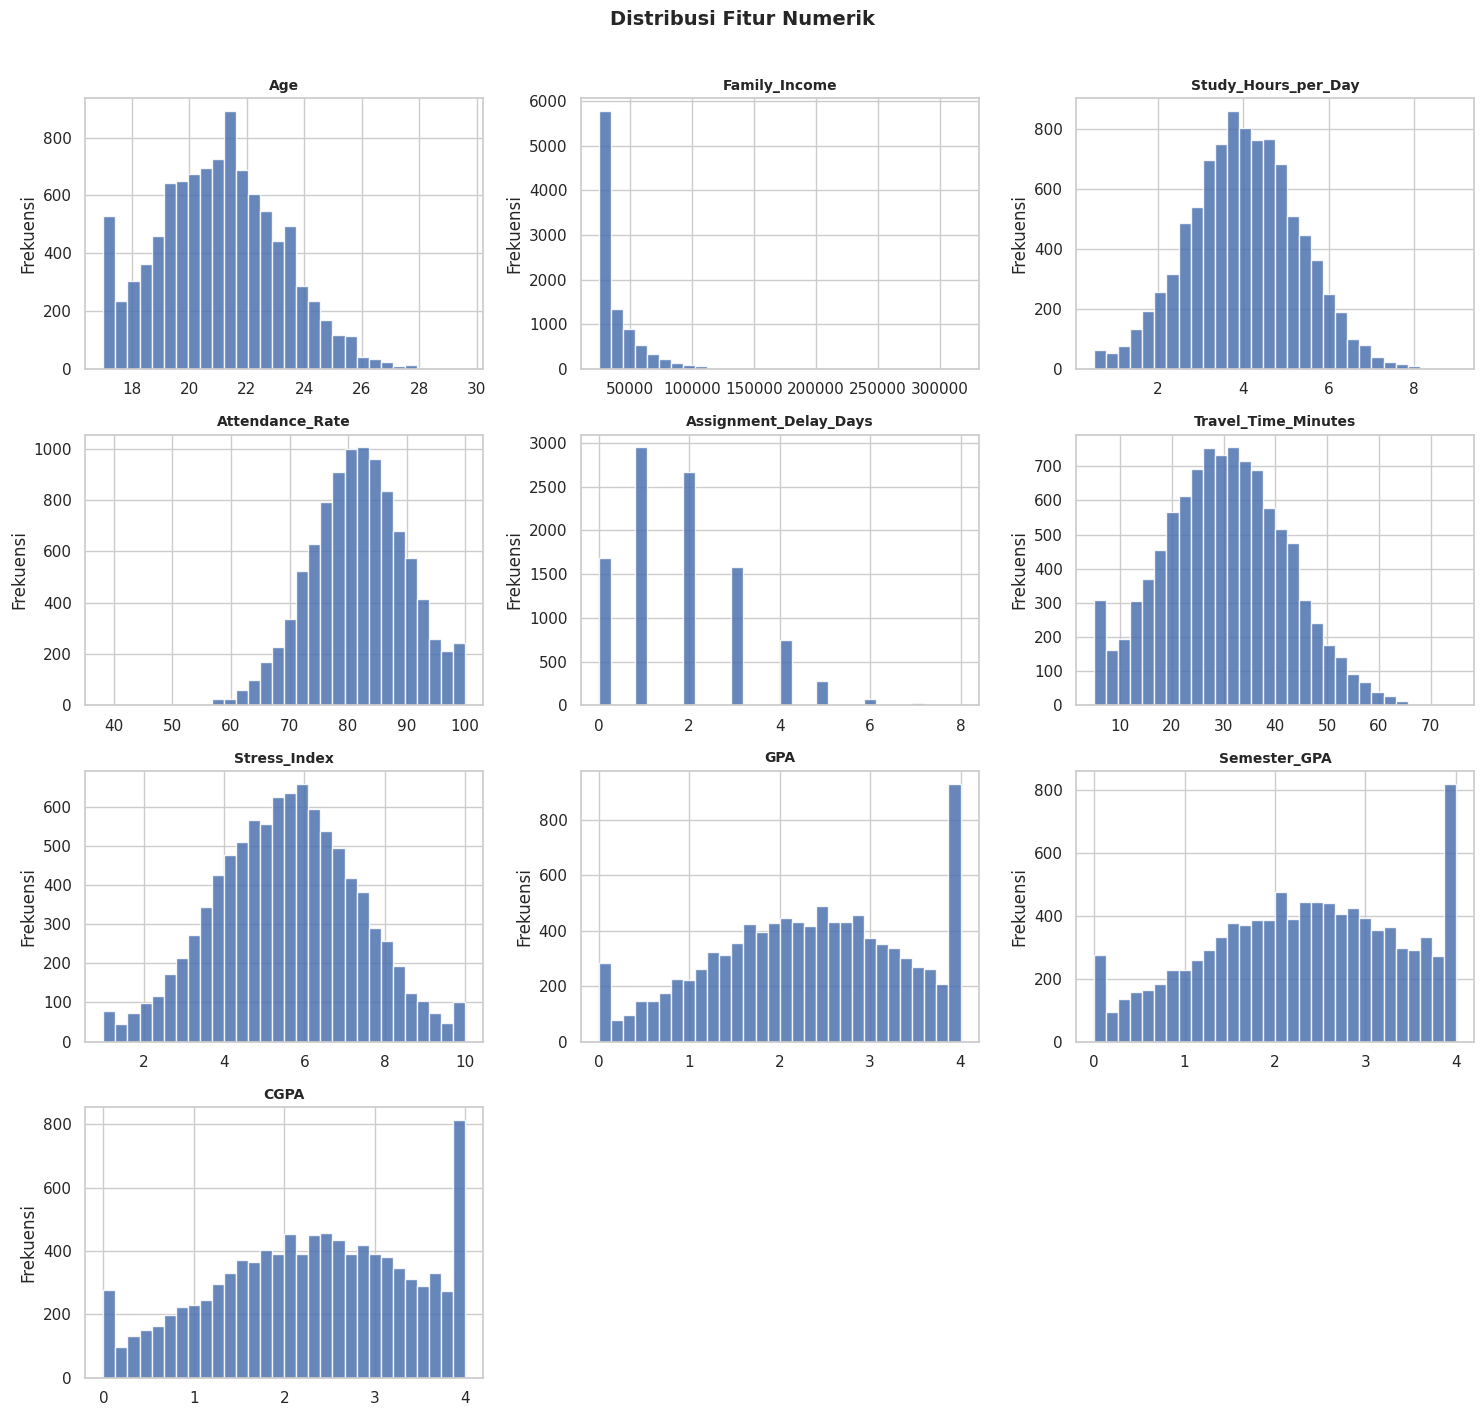

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

plot_numeric = [c for c in numeric_cols if c != target_col and c != "Student_ID"]

n_cols = 3
n_rows = (len(plot_numeric) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_numeric):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frekuensi")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Boxplot Fitur Numerik terhadap Target (Deteksi Outlier)

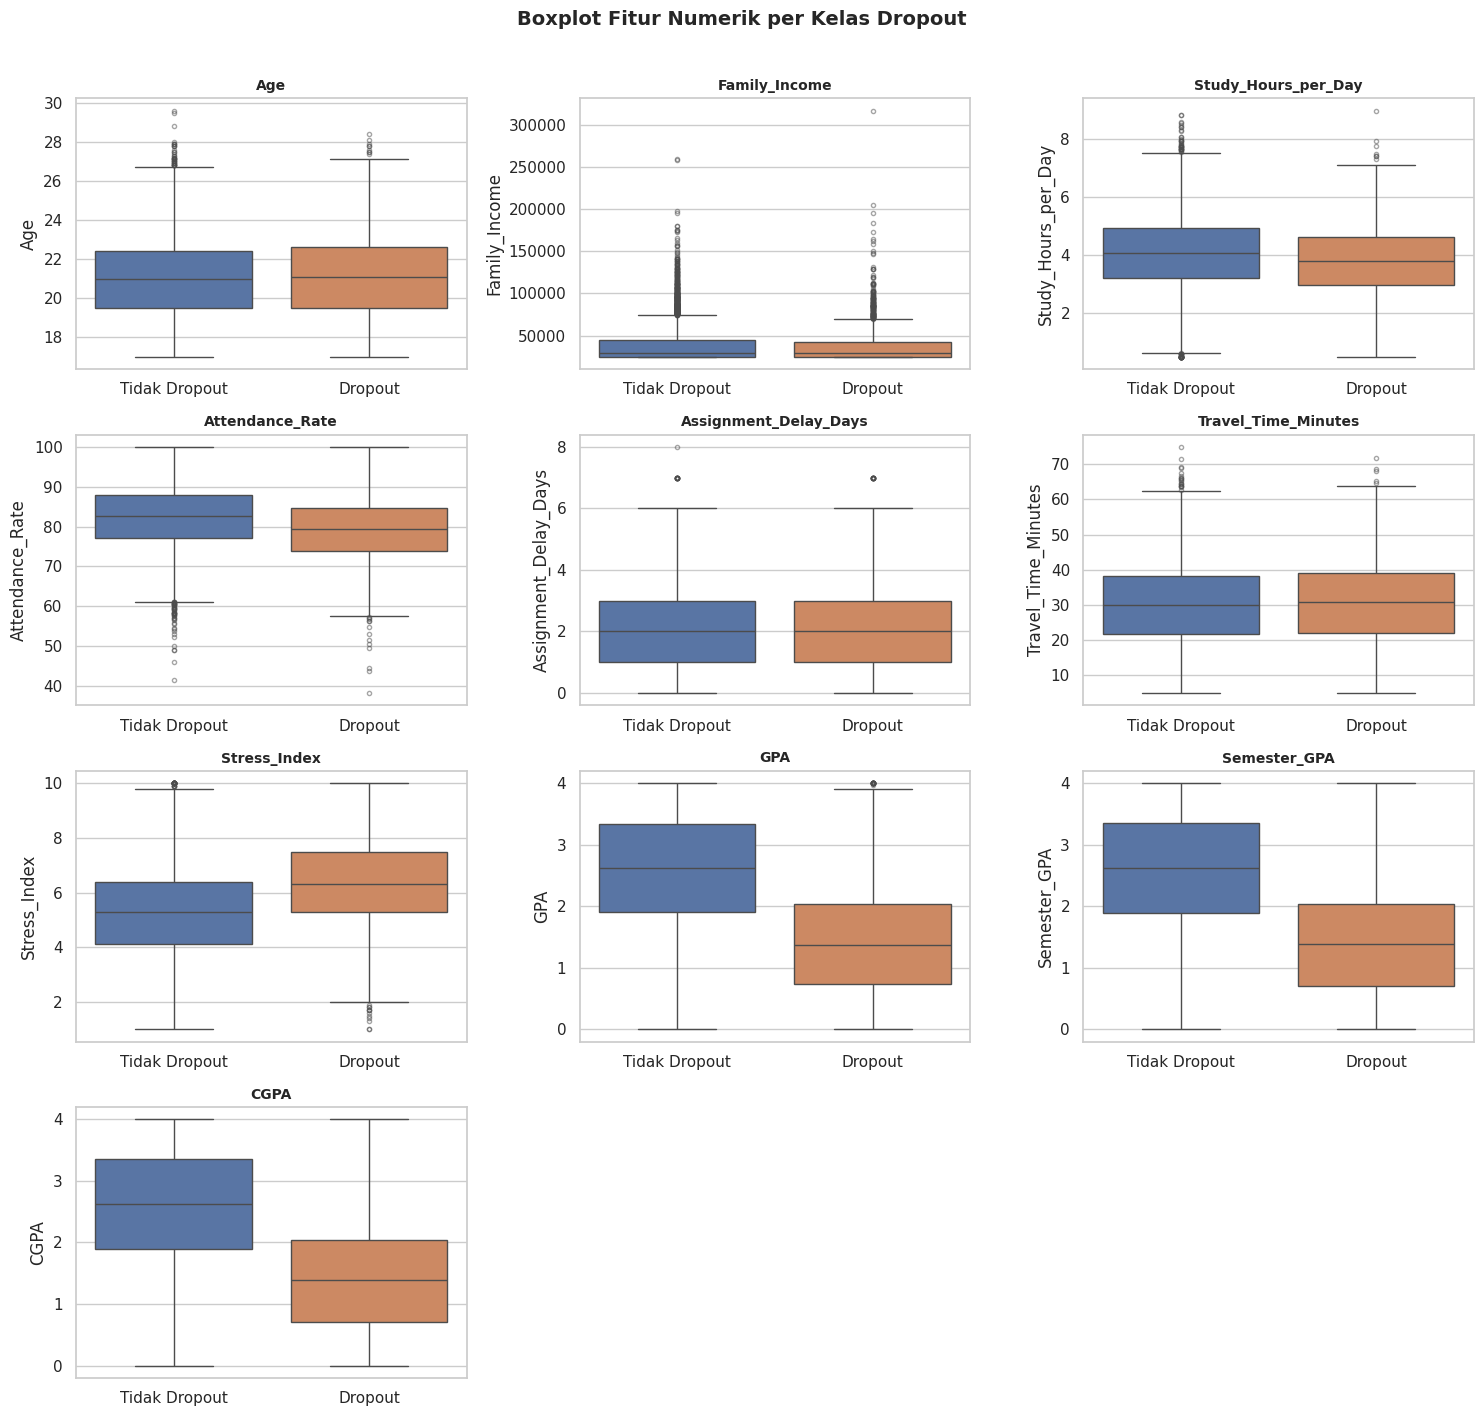

In [10]:
df_plot = df.copy()
df_plot[target_col] = df_plot[target_col].map({0: "Tidak Dropout", 1: "Dropout"})

n_cols = 3
n_rows = (len(plot_numeric) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

palette = {"Tidak Dropout": "#4C72B0", "Dropout": "#DD8452"}

for i, col in enumerate(plot_numeric):
    sns.boxplot(data=df_plot, x=target_col, y=col, palette=palette, ax=axes[i],
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot Fitur Numerik per Kelas Dropout", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Distribusi Fitur Kategorikal

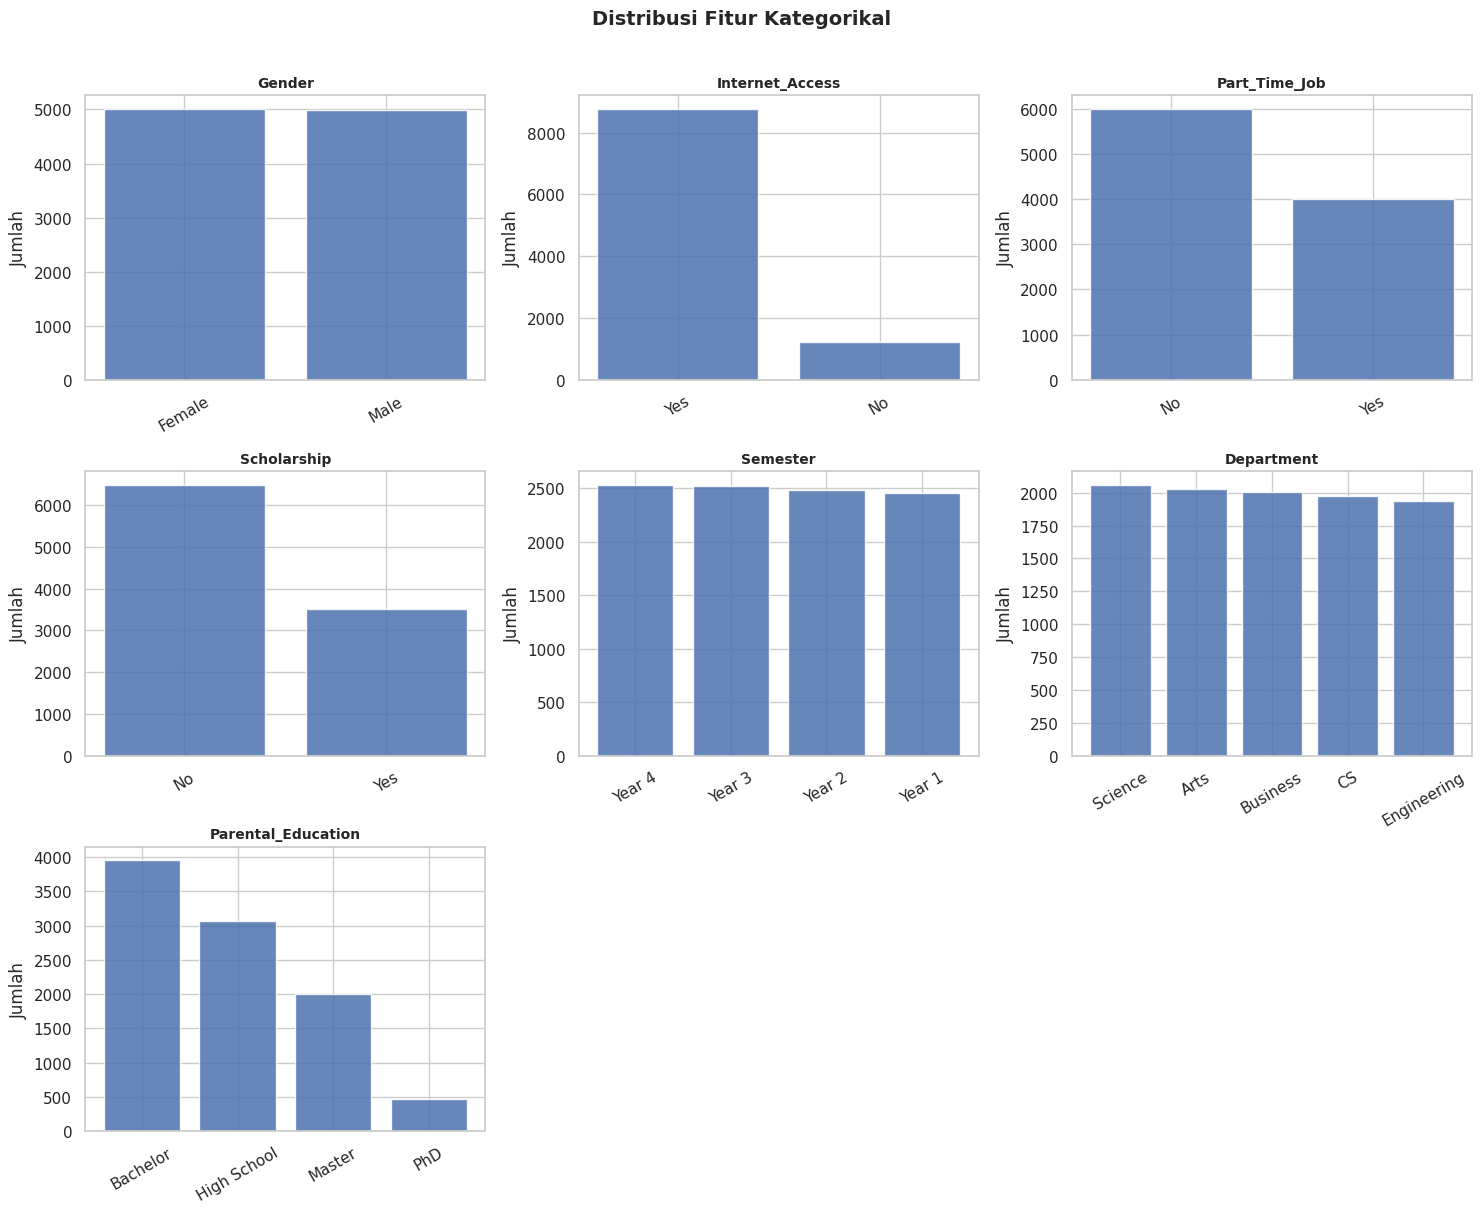

In [11]:
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col]

if len(cat_cols) == 0:
    print("Tidak ada fitur kategorikal (selain target).")
else:
    n_cols = 3
    n_rows = (len(cat_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        counts = df[col].value_counts()
        axes[i].bar(counts.index.astype(str), counts.values, color="#4C72B0", edgecolor="white", alpha=0.85)
        axes[i].set_title(col, fontsize=10, fontweight="bold")
        axes[i].set_ylabel("Jumlah")
        axes[i].tick_params(axis="x", rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribusi Fitur Kategorikal", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


### Correlation Heatmap (Fitur Numerik)

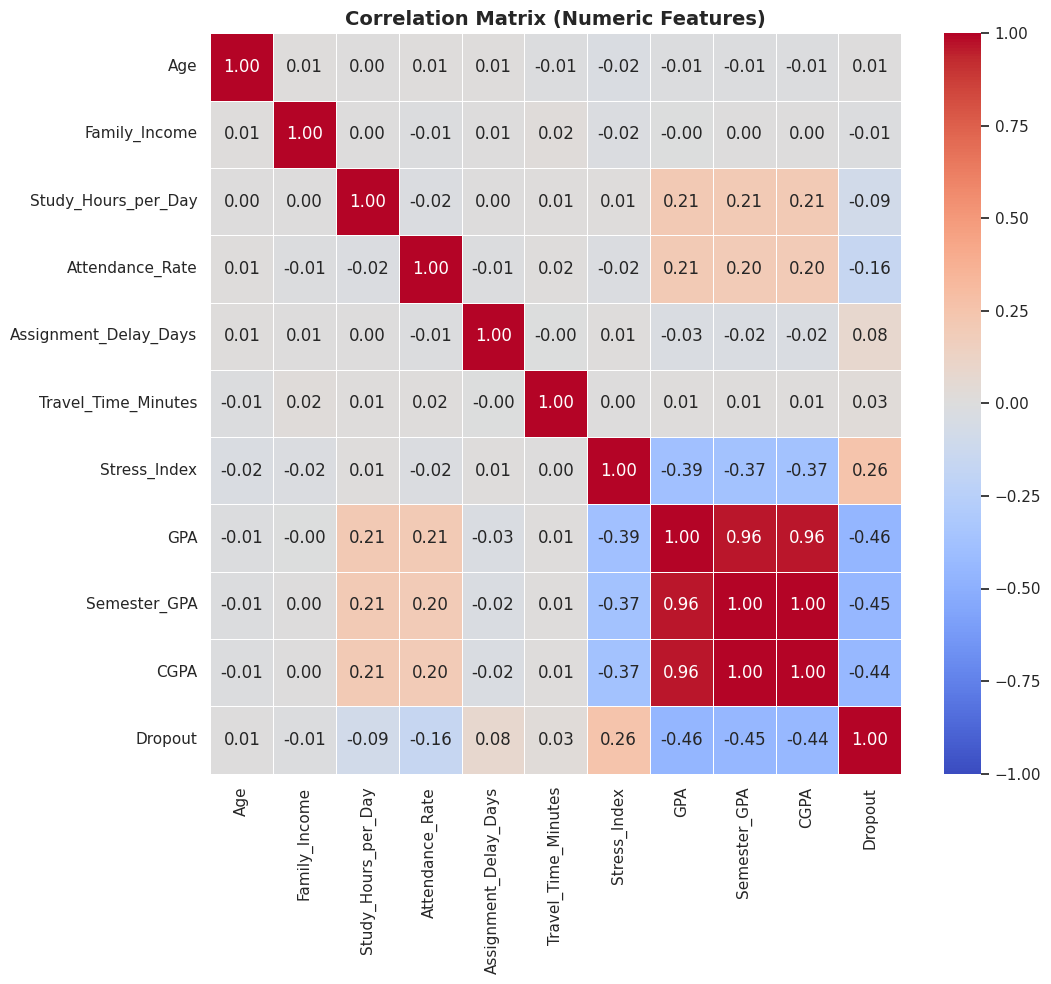

In [12]:
numeric_features_for_corr = [c for c in df.select_dtypes(include=["int64", "float64"]).columns.tolist() if c not in ["Student_ID"]]

correlation_matrix = df[numeric_features_for_corr].corr()

plt.figure(figsize=(max(8, len(numeric_features_for_corr)), max(6, len(numeric_features_for_corr) - 1)))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Data Preprocessing**

Tahap ini mencakup:
- Hapus kolom non-informatif (misal `Student_ID`)
- Hapus duplikat
- Pisahkan fitur (X) dan target (y)
- Definisikan pipeline preprocessing numerik & kategorikal


In [13]:
# Hapus Duplikat
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Baris dihapus (duplikat): {before - df.shape[0]}")

Baris dihapus (duplikat): 0


In [14]:
# Pisahkan Fitur dan Target
drop_columns = [target_col]
if "Student_ID" in df.columns:
    drop_columns.append("Student_ID")

# 'CGPA', 'GPA' dan 'Semester_GPA' terdapat indikasi multicollinearity, dan terindikasi bias
drop_columns.extend(["CGPA", "Semester_GPA", 'Age', "Gender", "Parental_Education", "Family_Income", "Department"])

In [15]:
X = df.drop(columns=drop_columns)
y = df[target_col]

# Identifikasi tipe kolom
numeric_features     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"\nJumlah fitur total       : {X.shape[1]}")
print(f"   Fitur numerik           : {len(numeric_features)}")
print(f"   Fitur kategorikal       : {len(categorical_features)}")
print(f"\nFitur numerik    : {numeric_features}")
print(f"Fitur kategorikal: {categorical_features}")


Jumlah fitur total       : 10
   Fitur numerik           : 6
   Fitur kategorikal       : 4

Fitur numerik    : ['Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA']
Fitur kategorikal: ['Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester']


In [16]:
# Pipeline Preprocessing
# Numerik   : Imputasi median → StandardScaler
# Kategorikal: Imputasi modus → OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Pipeline preprocessing telah didefinisikan.")
print("   • Numerik  : SimpleImputer(median) → StandardScaler")
print("   • Kategorikal: SimpleImputer(most_frequent) → OneHotEncoder")


Pipeline preprocessing telah didefinisikan.
   • Numerik  : SimpleImputer(median) → StandardScaler
   • Kategorikal: SimpleImputer(most_frequent) → OneHotEncoder


## **Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Data training  : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Data testing   : {X_test.shape[0]} baris  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribusi kelas - Training:")
print((y_train.value_counts(normalize=True) * 100).round(2).to_string())
print(f"\nDistribusi kelas - Testing:")
print((y_test.value_counts(normalize=True) * 100).round(2).to_string())


Data training  : 8000 baris (80.0%)
Data testing   : 2000 baris  (20.0%)

Distribusi kelas - Training:
Dropout
0    76.46
1    23.54

Distribusi kelas - Testing:
Dropout
0    76.45
1    23.55


## **Modeling & Training**


In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Definisikan model yang akan digunakan
models = {
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors"  : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"        : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM"                  : SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

In [19]:
# Pelatihan model dengan SMOTE
results_list = []
trained_models = {}

for model_name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results_list.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4) if not np.isnan(auc) else "-"
    })
    trained_models[model_name] = pipeline
    print(f"{model_name:<25} | Acc: {acc*100:.2f}%  Rec: {rec:.4f}  F1: {f1:.4f}")

results_df = pd.DataFrame(results_list).sort_values("Recall", ascending=False).reset_index(drop=True)
print("\nHasil Model (Urutan berdasarkan Recall):")
display(results_df)

Logistic Regression       | Acc: 74.35%  Rec: 0.7580  F1: 0.5819
K-Nearest Neighbors       | Acc: 68.00%  Rec: 0.6539  F1: 0.4904
Decision Tree             | Acc: 70.35%  Rec: 0.4926  F1: 0.4390
Random Forest             | Acc: 78.00%  Rec: 0.5839  F1: 0.5556
Gradient Boosting         | Acc: 77.75%  Rec: 0.6476  F1: 0.5782
SVM                       | Acc: 72.70%  Rec: 0.7304  F1: 0.5575

Hasil Model (Urutan berdasarkan Recall):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7435,0.4722,0.7580,0.5819,0.8195
1,SVM,0.7270,0.4509,0.7304,0.5575,0.7948
2,K-Nearest Neighbors,0.6800,0.3924,0.6539,0.4904,0.7265
3,Gradient Boosting,0.7775,0.5223,0.6476,0.5782,0.8148
4,Random Forest,0.7800,0.5299,0.5839,0.5556,0.8016
5,Decision Tree,0.7035,0.3959,0.4926,0.4390,0.6305


## **Evaluasi Model**

### Visualisasi Perbandingan Metrik

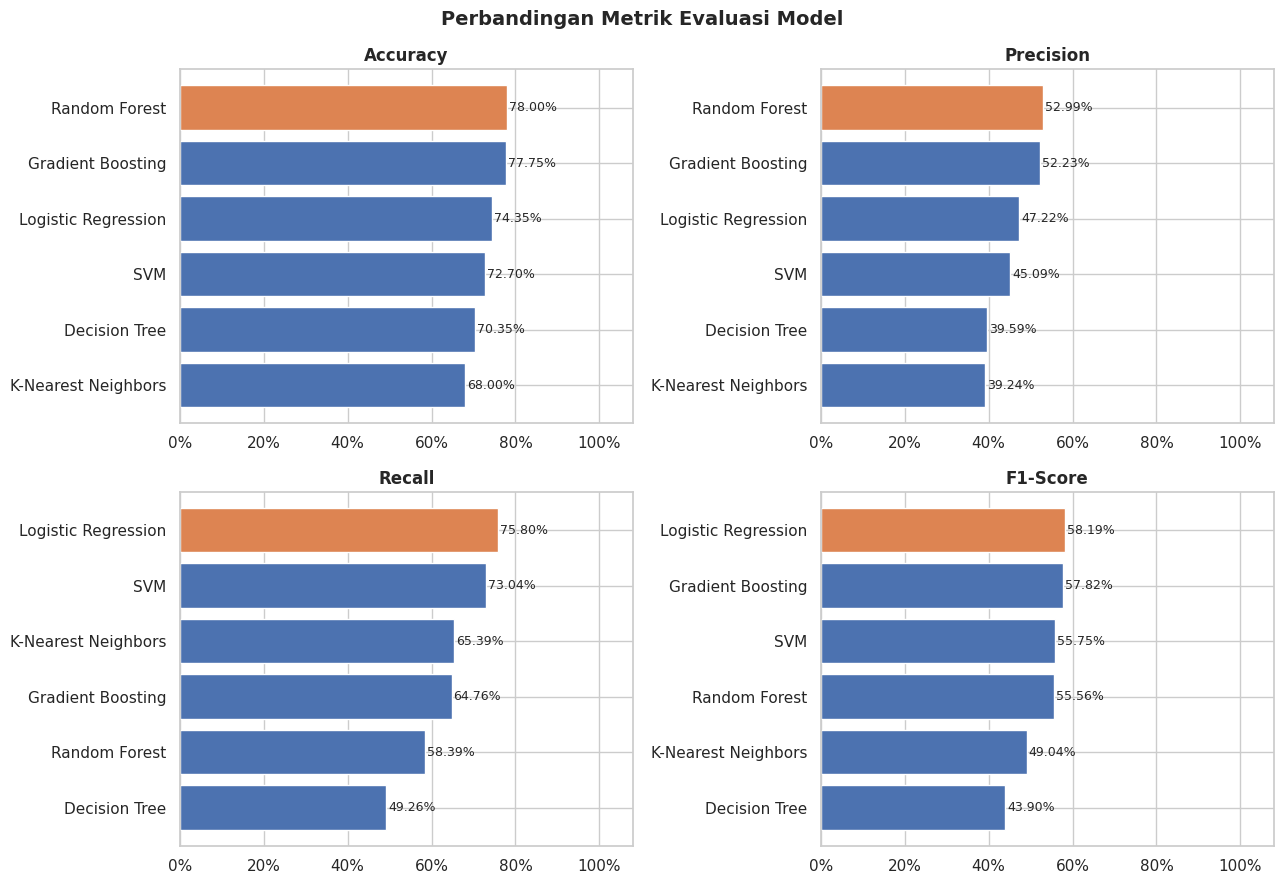

In [20]:
metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_data = results_df.set_index("Model")[metrics].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sorted_data = plot_data[metric].sort_values()
    colors = ["#DD8452" if v == sorted_data.max() else "#4C72B0" for v in sorted_data]
    bars = axes[i].barh(sorted_data.index, sorted_data, color=colors, edgecolor="white")
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_xlim(0, 1.08)
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{width*100:.2f}%", va="center", fontsize=9)

plt.suptitle("Perbandingan Metrik Evaluasi Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Classification Report

In [21]:
print("  Classification Report - Performa Model")
print("=" * 55)

for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    print(f"Model: {model_name}")
    print("-" * 55)
    print(classification_report(
        y_test, y_pred,
        target_names=["Tidak Dropout", "Dropout"],
        zero_division=0
    ))
    print("\n")

  Classification Report - Performa Model
Model: Logistic Regression
-------------------------------------------------------
               precision    recall  f1-score   support

Tidak Dropout       0.91      0.74      0.82      1529
      Dropout       0.47      0.76      0.58       471

     accuracy                           0.74      2000
    macro avg       0.69      0.75      0.70      2000
 weighted avg       0.81      0.74      0.76      2000



Model: K-Nearest Neighbors
-------------------------------------------------------
               precision    recall  f1-score   support

Tidak Dropout       0.87      0.69      0.77      1529
      Dropout       0.39      0.65      0.49       471

     accuracy                           0.68      2000
    macro avg       0.63      0.67      0.63      2000
 weighted avg       0.75      0.68      0.70      2000



Model: Decision Tree
-------------------------------------------------------
               precision    recall  f1-score  

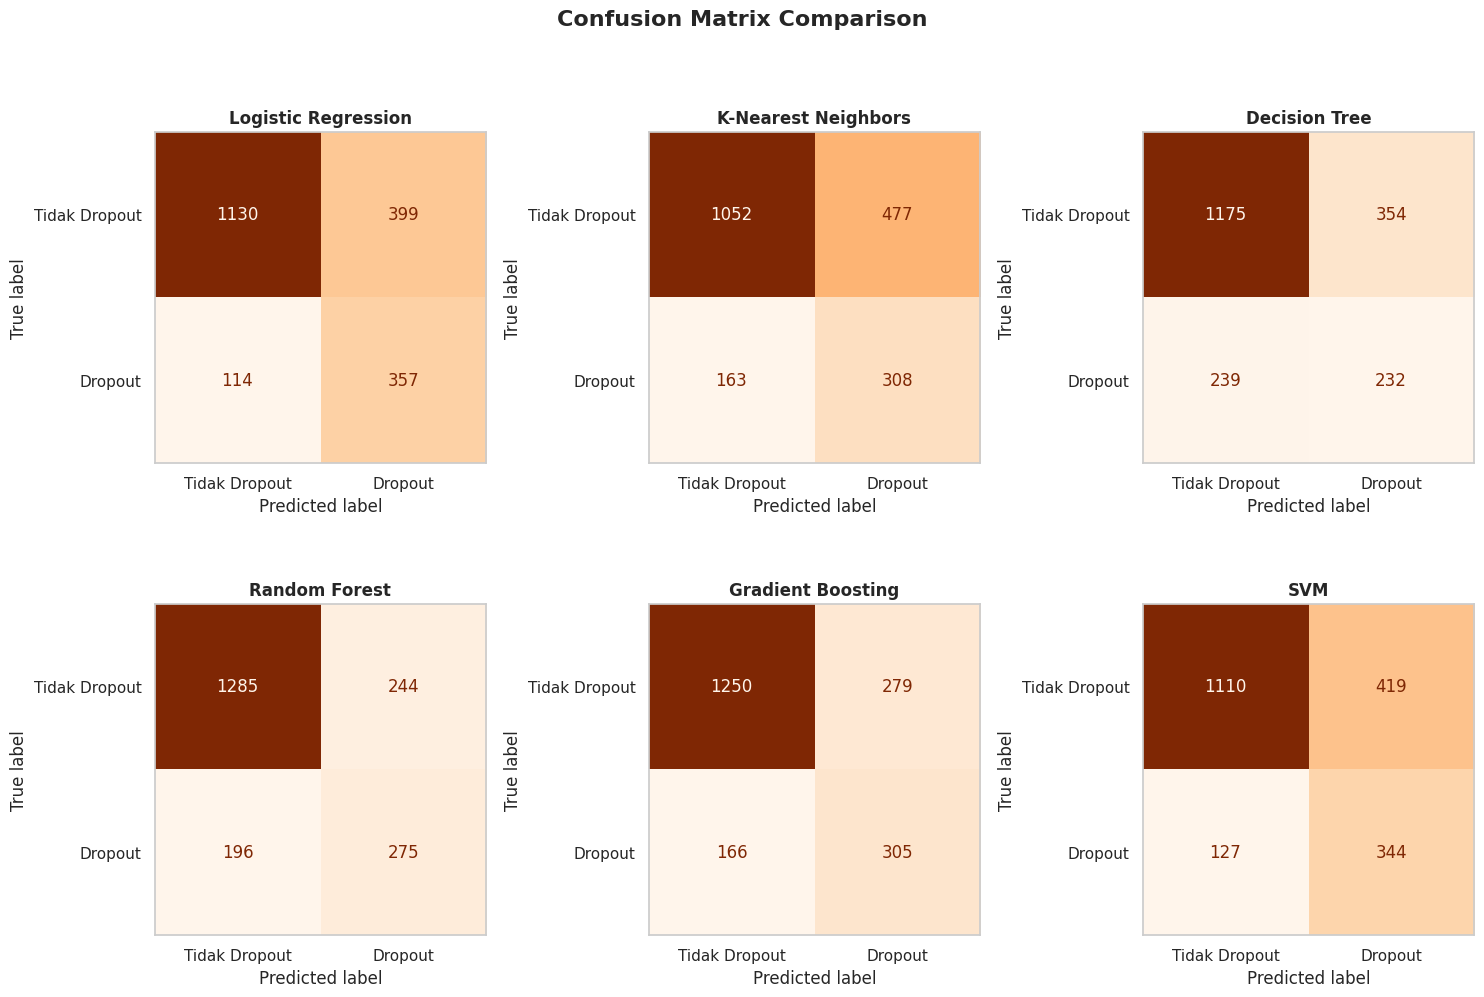

In [22]:
n_models = len(trained_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (model_name, pipeline) in enumerate(trained_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Dropout", "Dropout"])
    disp.plot(ax=axes[i], cmap="Oranges", colorbar=False)
    axes[i].set_title(f"{model_name}", fontsize=12, fontweight="bold")
    axes[i].grid(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Confusion Matrix – Model Terbaik

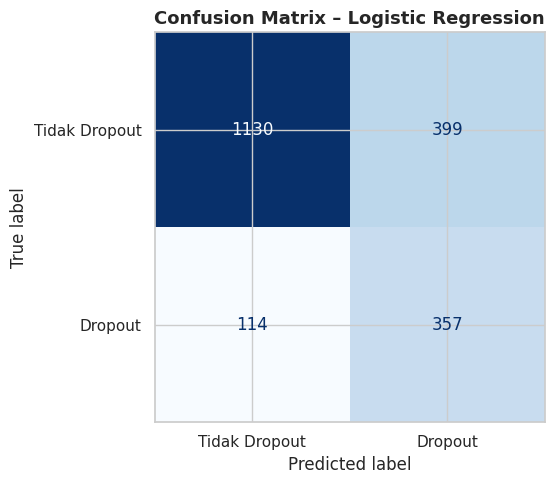

True Positive  (TP): 357  — Dropout terdeteksi dengan benar
True Negative  (TN): 1130  — Tidak Dropout terdeteksi dengan benar
False Positive (FP): 399  — Salah prediksi Dropout
False Negative (FN): 114  — Mahasiswa Dropout yang terlewat


In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Dropout", "Dropout"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix – {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positive  (TP): {tp}  — Dropout terdeteksi dengan benar")
print(f"True Negative  (TN): {tn}  — Tidak Dropout terdeteksi dengan benar")
print(f"False Positive (FP): {fp}  — Salah prediksi Dropout")
print(f"False Negative (FN): {fn}  — Mahasiswa Dropout yang terlewat")


### ROC Curve – Semua Model

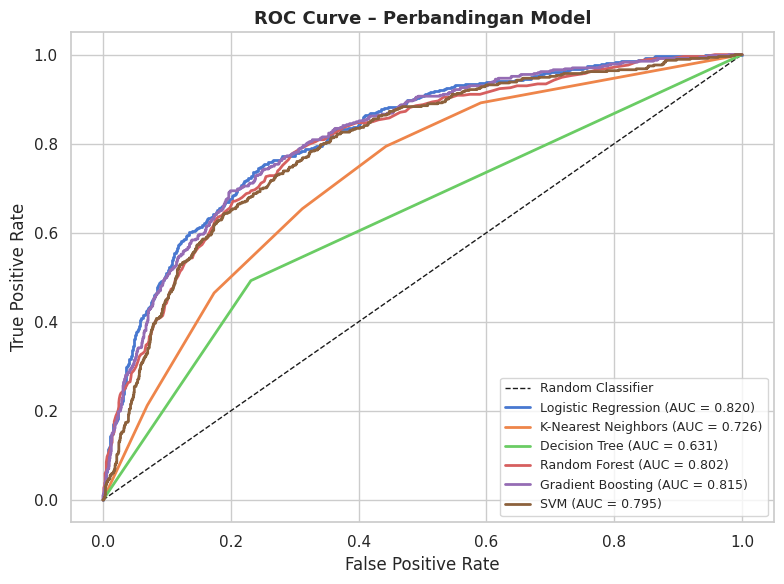

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")

for name, pipeline in trained_models.items():
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        proba = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc_score    = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – Perbandingan Model", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Feature Importance

In [25]:
lr_pipeline = trained_models['Logistic Regression']
lr_model_obj = lr_pipeline.named_steps['model']

coefficients = lr_model_obj.coef_[0]

feature_names = numeric_features.copy()
if categorical_features:
    onehot = lr_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    encoded_cats = onehot.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(encoded_cats)

fi_lr_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print('Koefisien Fitur Logistic Regression:')
display(fi_lr_df.head(15))

Koefisien Fitur Logistic Regression:


,Feature,Coefficient,Abs_Coefficient
0,GPA,-1.262264,1.262264
1,Stress_Index,0.309133,0.309133
2,Assignment_Delay_Days,0.248695,0.248695
3,Attendance_Rate,-0.239672,0.239672
4,Part_Time_Job_No,-0.177313,0.177313
5,Internet_Access_Yes,-0.137767,0.137767
6,Travel_Time_Minutes,0.125791,0.125791
7,Semester_Year 1,-0.117075,0.117075
8,Scholarship_Yes,-0.113611,0.113611
9,Semester_Year 4,-0.046868,0.046868


### Pengujian Data Baru & Explainable AI (SHAP)

In [26]:
# 1. Simulasi Data Baru
data_baru = pd.DataFrame({
    'Internet_Access': ['No'],
    'Study_Hours_per_Day': [10],
    'Attendance_Rate': [30.0],
    'Assignment_Delay_Days': [5],
    'Travel_Time_Minutes': [15.0],
    'Part_Time_Job': ['Yes'],
    'Scholarship': ['Yes'],
    'Stress_Index': [5.5],
    'GPA': [3.0],
    'Semester': ['Year 3']
})

# Menggunakan Logistic Regression karena memiliki performa Recall yang baik
model_final = trained_models['Logistic Regression']

# Prediksi
prediksi = model_final.predict(data_baru)
probabilitas = model_final.predict_proba(data_baru)

status = "Dropout" if prediksi[0] == 1 else "Tidak Dropout"
print(f"--- Hasil Prediksi Data Baru ---")
display(data_baru)
print(f"\nHasil Prediksi: {status}")
print(f"Probabilitas Dropout: {probabilitas[0][1]:.2%}")

--- Hasil Prediksi Data Baru ---


,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester
0,No,10,30.0,5,15.0,Yes,Yes,5.5,3.0,Year 3



Hasil Prediksi: Dropout
Probabilitas Dropout: 67.01%



--- Interpretasi SHAP ---


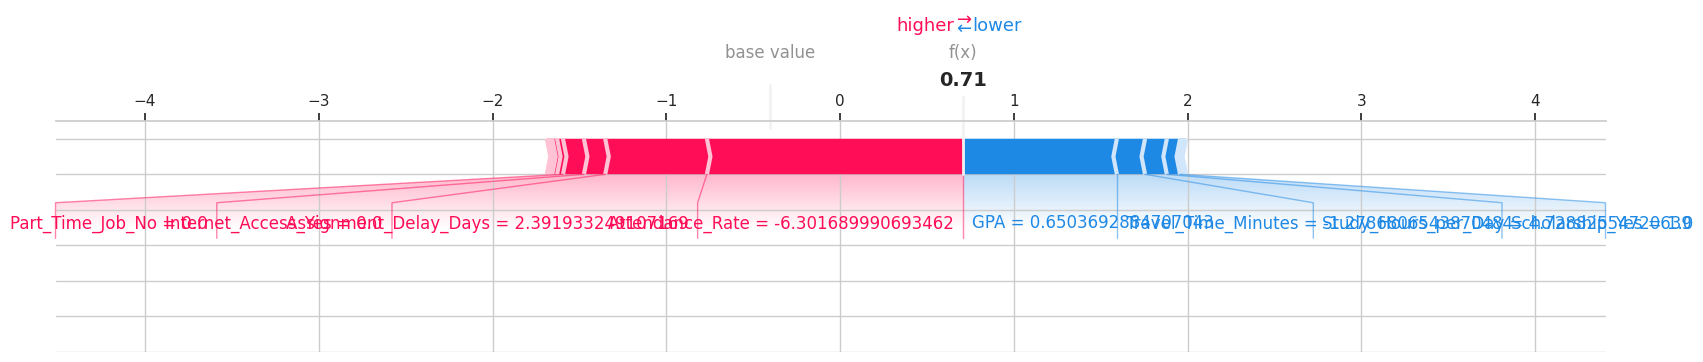

In [27]:
# Explainable AI dengan SHAP
preprocessor_obj = model_final.named_steps['preprocessor']
X_test_transformed = preprocessor_obj.transform(X_test)
X_new_transformed = preprocessor_obj.transform(data_baru)

explainer = shap.LinearExplainer(
    model_final.named_steps['model'],
    X_test_transformed,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_new_transformed)

print("\n--- Interpretasi SHAP ---")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_new_transformed[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()


--- SHAP Summary Plot (Feature Importance across Test Set) ---


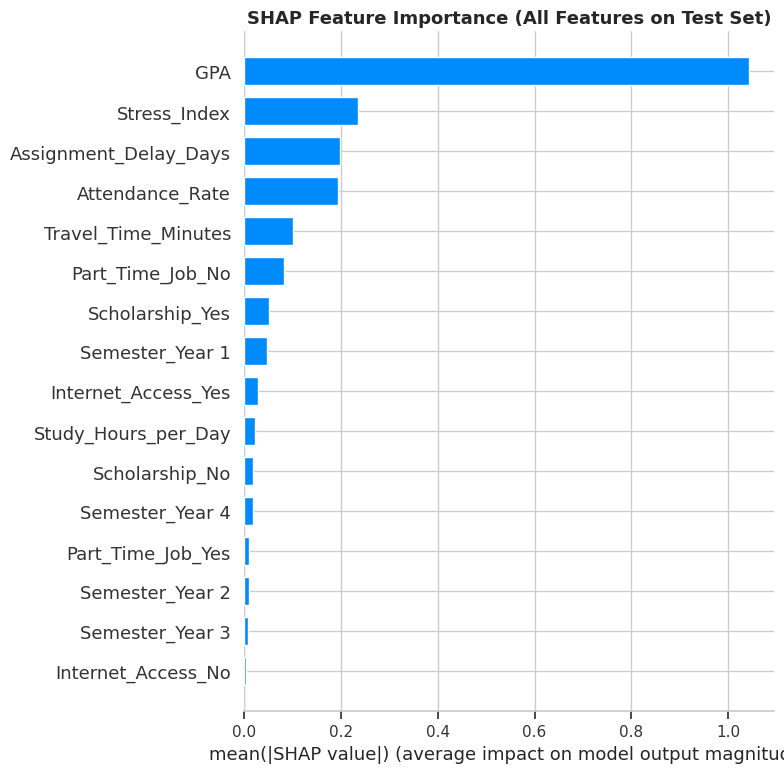


--- SHAP Bar Plot for the New Prediction ---


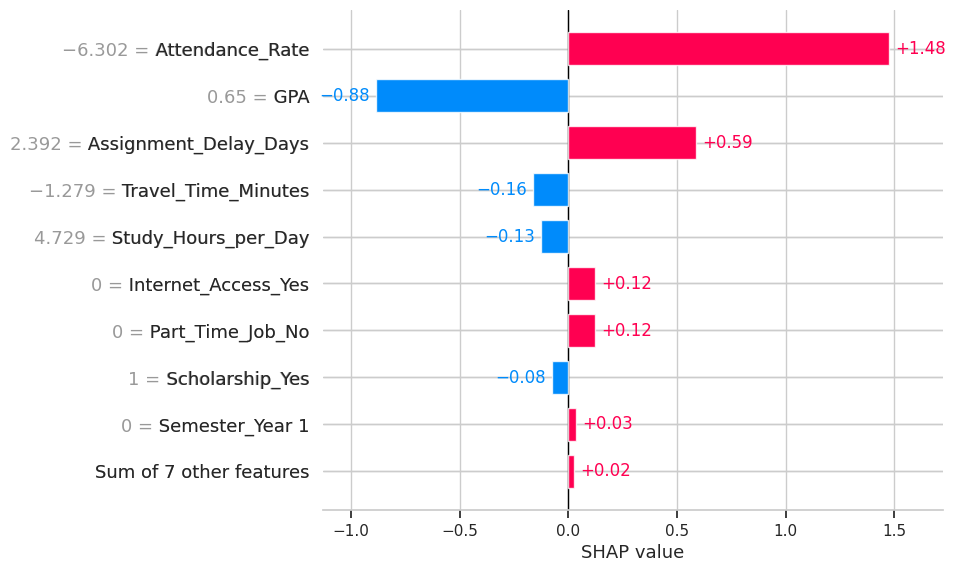

In [28]:
shap_values_test = explainer.shap_values(X_test_transformed)

print("\n--- SHAP Summary Plot (Feature Importance across Test Set) ---")
shap.summary_plot(shap_values_test, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (All Features on Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n--- SHAP Bar Plot for the New Prediction ---")
shap.plots.bar(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_new_transformed[0], feature_names=feature_names))

### Export Model


In [29]:
# Ambil komponen dari trained pipeline
best_pipeline = trained_models['Logistic Regression']
preprocessor_obj = best_pipeline.named_steps['preprocessor']
lr_model = best_pipeline.named_steps['model']

# Buat clean pipeline tanpa imblearn
clean_pipeline = SklearnPipeline([
    ('preprocessor', preprocessor_obj),
    ('model', lr_model)
])

# Export
joblib.dump(clean_pipeline, 'logistic_regression_model.pkl')
print("Model saved!")

Model saved!


## Kesimpulan

### Ringkasan Performa Model
Berdasarkan hasil pengujian pada 6 algoritma berbeda, kami mendapatkan beberapa temuan:

1.  Model Terbaik untuk Deteksi Dropout adalah **Logistic Regression** dengan menunjukkan performa terbaik dalam Recall (75.80%). Dalam konteks prediksi mahasiswa dropout, metrik Recall sangat krusial karena kita ingin meminimalisir 'False Negative' (mahasiswa yang sebenarnya berisiko dropout namun tidak terdeteksi).
2. Meskipun Random Forest memiliki akurasi yang lebih tinggi (~78%), namun Logistic Regression lebih unggul dalam menangkap sinyal dropout pada data yang sudah di-handle menggunakan **SMOTE**.
3. Kurva ROC menunjukkan bahwa sebagian besar model memiliki kemampuan yang baik (AUC > 0.70) dalam membedakan antara kelas mahasiswa yang tetap lanjut dan yang dropout.

### Feature Importance via SHAP
Dari hasil yang ditunjukkan menggunakan SHAP, diperolah sebagai berikut:
-   Attendance Rate menjadi faktor paling signifikan, tingkat kehadiran yang rendah sangat berkorelasi dengan risiko dropout.
-   Study Hours & GPA memiliki pengaruh besar dalam menjaga probabilitas tetap rendah.
-  Keterlambatan pengumpulan tugas menjadi indikator awal yang kuat bagi mahasiswa yang mulai kesulitan secara akademik.

### Rekomendasi
Model **Logistic Regression** yang telah disimpan (`logistic_regression_model.pkl`) dapat digunakan sebagai sistem peringatan dini (early warning system). Mahasiswa dengan probabilitas dropout di atas 50% (seperti pada contoh simulasi data baru yang mencapai 67.01%) perlu mendapatkan intervensi atau bimbingan akademik lebih awal.